### IMPORTAZIONE LIBRERIE

In [76]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

print ("librerie")
print("prova")

librerie
prova


#### Definizione stile grafico: sfondo bianco,griglia leggera,grafici moderni

In [77]:
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

#### Read dataset fumatori italia

In [78]:
df = pd.read_csv('fumatori_italia.csv')

### OSSERVAZIONE HEAD E TAIL
#### Abbiamo osservato la parte iniziale e finale del dataset per vedere come era composto

In [79]:
df.head()

,Anno,Sesso,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
0,1980,Maschi,52.3,48.6,53.0,61.5,56.5,54.3
1,1983,Maschi,45.3,41.0,44.5,50.6,46.1,45.6
2,1987,Maschi,42.3,34.7,39.3,43.8,43.3,40.8
3,1990,Maschi,37.6,31.7,37.5,41.7,40.9,37.8
4,1993,Maschi,34.6,29.4,34.8,38.8,38.6,35.1


In [80]:
df.tail()

,Anno,Sesso,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
47,2011,Femmine,18.0,16.2,19.2,14.3,14.1,16.6
48,2012,Femmine,17.9,16.5,17.8,13.5,16.3,16.4
49,2013,Femmine,16.1,15.6,18.6,13.2,15.5,15.8
50,2014,Femmine,15.5,14.9,15.9,12.7,14.8,14.7
51,2015,Femmine,15.4,15.4,17.3,12.6,14.4,15.0


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Anno        52 non-null     int64  
 1   Sesso       52 non-null     str    
 2   Nord_ovest  52 non-null     float64
 3   Nord_est    52 non-null     float64
 4   Centro      52 non-null     float64
 5   Sud         52 non-null     float64
 6   Isole       52 non-null     float64
 7   Italia      52 non-null     float64
dtypes: float64(6), int64(1), str(1)
memory usage: 3.4 KB


In [82]:
df.describe()

,Anno,Nord_ovest,Nord_est,Centro,Sud,Isole,Italia
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000
mean,2001.076923,24.800000,23.053846,25.826923,24.505769,24.794231,24.609615
std,9.480312,8.541571,6.759089,8.024768,12.101376,10.905070,9.128693
min,1980.000000,15.400000,14.900000,15.900000,11.900000,11.700000,14.700000
25%,1995.000000,17.875000,18.075000,19.375000,13.950000,15.175000,16.975000
50%,2001.500000,21.650000,21.400000,22.750000,21.300000,21.250000,21.250000
75%,2009.000000,30.150000,27.400000,31.675000,33.025000,32.850000,31.050000
max,2015.000000,52.300000,48.600000,53.000000,61.500000,56.500000,54.300000


### MINIMO E MASSIMO:


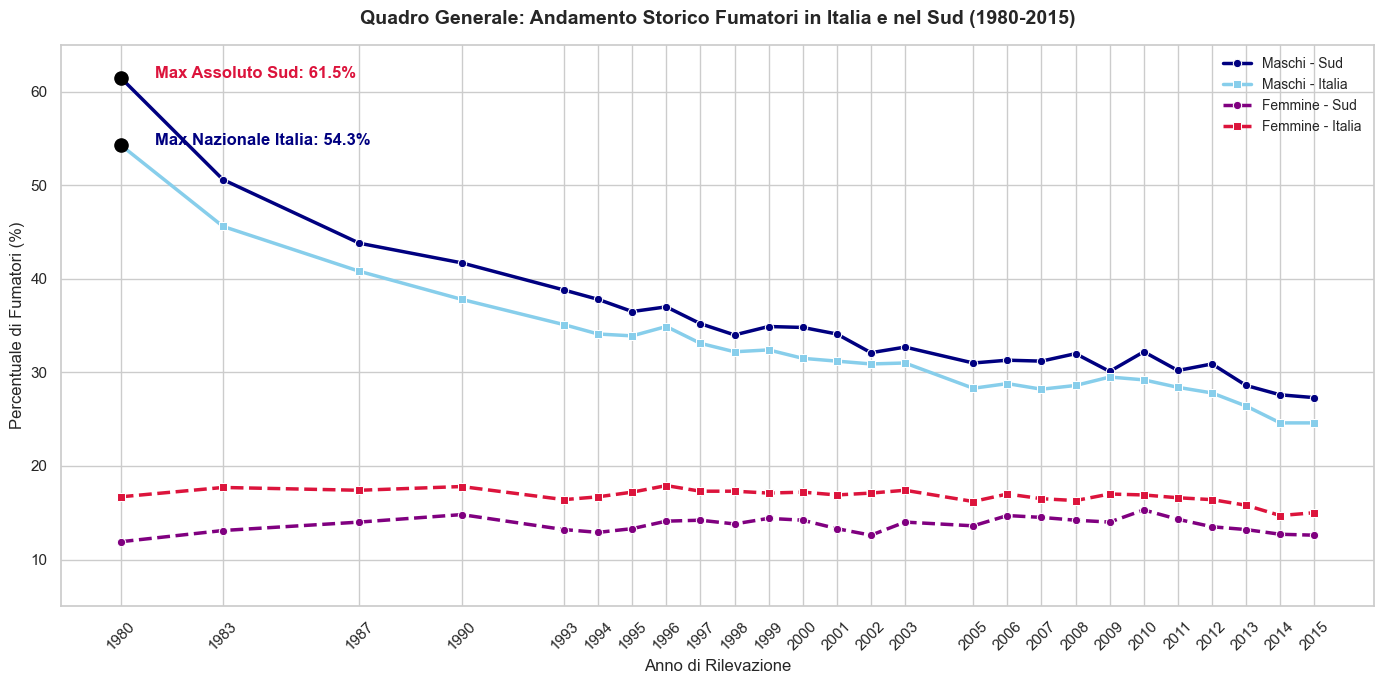

In [83]:

# Configurazione dello stile del grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# 1. Grafico per i Maschi (linee continue)
sns.lineplot(
    data=df[df["Sesso"] == "Maschi"],
    x="Anno",
    y="Sud",
    label="Maschi - Sud ",
    marker="o",
    linestyle="-",
    color="navy",
    linewidth=2.5,
)
sns.lineplot(
    data=df[df["Sesso"] == "Maschi"],
    x="Anno",
    y="Italia",
    label="Maschi - Italia ",
    marker="s",
    linestyle="-",
    color="skyblue",
    linewidth=2.5,
)

# 2. Grafico per le Femmine (linee tratteggiate)
sns.lineplot(
    data=df[df["Sesso"] == "Femmine"],
    x="Anno",
    y="Sud",
    label="Femmine - Sud",
    marker="o",
    linestyle="--",
    color="purple",
    linewidth=2.5,
)
sns.lineplot(
    data=df[df["Sesso"] == "Femmine"],
    x="Anno",
    y="Italia",
    label="Femmine - Italia",
    marker="s",
    linestyle="--",
    color="crimson",
    linewidth=2.5,
)

# punti di massimo assoluto del 1980 (Maschi)
plt.scatter([1980, 1980], [61.5, 54.3], color="black", s=90, zorder=5)
plt.text(
    1981,
    61.5,
    "Max Assoluto Sud: 61.5%",
    fontweight="bold",
    color="crimson",
)
plt.text(
    1981,
    54.3,
    "Max Nazionale Italia: 54.3%",
    fontweight="bold",
    color="navy",
)

# Configurazione 
plt.title(
    "Quadro Generale: Andamento Storico Fumatori in Italia e nel Sud (1980-2015)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Anno di Rilevazione", fontsize=12)
plt.ylabel("Percentuale di Fumatori (%)", fontsize=12)

plt.xticks(df["Anno"].unique(), rotation=45)
plt.ylim(5, 65)
plt.legend(loc="upper right", bbox_to_anchor=(1, 1), fontsize=10)

# Mostra il grafico ottimizzato
plt.tight_layout()
plt.show()

#### Il valore massimo in Italia arriva a 54.3.
#### Il valore massimo più alto si trova nel Sud, con 61.5.
#### Questo indica che nei primi anni del dataset la percentuale di fumatori era molto alta.

### MEDIA:


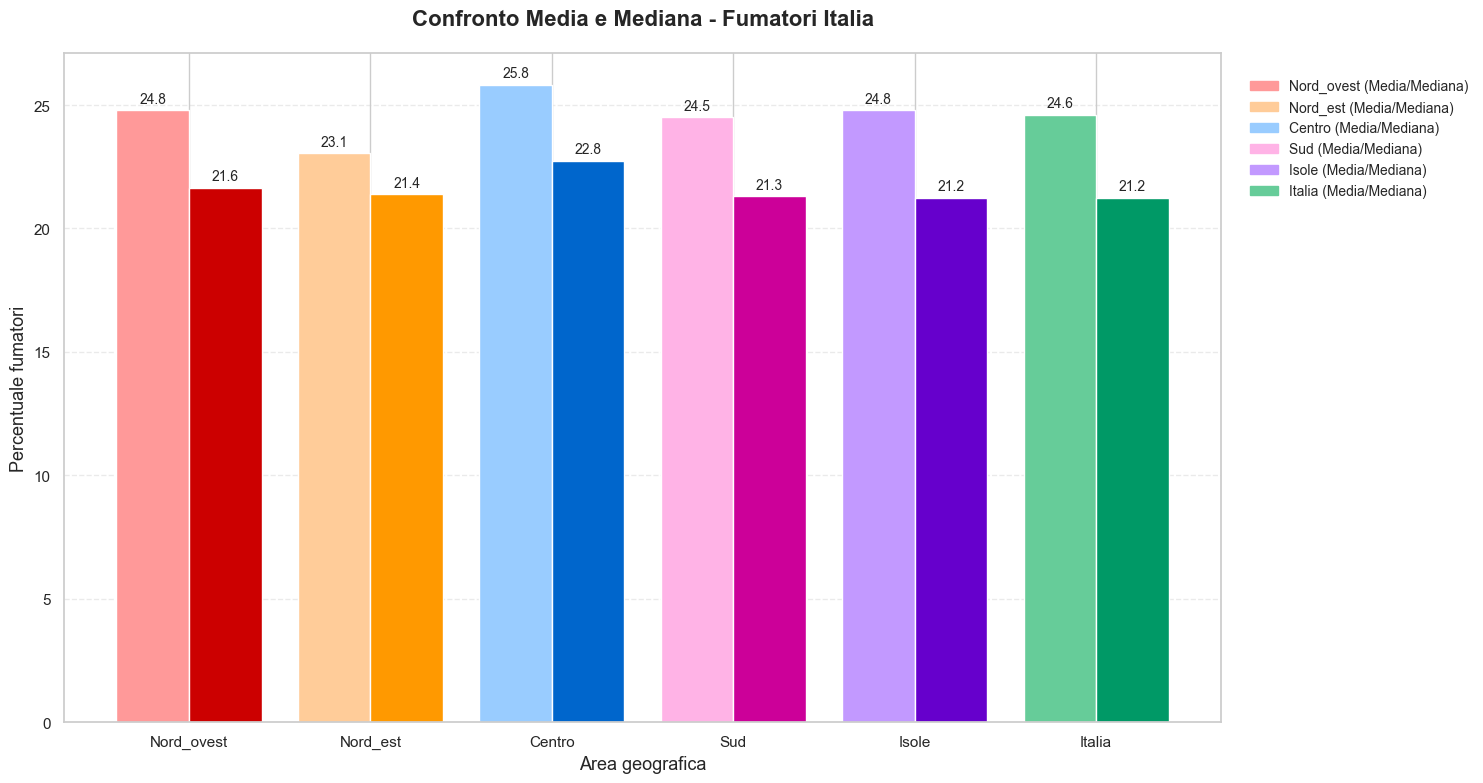

In [84]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Definizione delle colonne numeriche 
colonne_numeriche = ["Nord_ovest", "Nord_est", "Centro", "Sud", "Isole", "Italia"]

# Calcolo della media e della mediana 
media = df[colonne_numeriche].mean()
mediana = df[colonne_numeriche].median()

# Impostazione delle posizioni delle barre sull'asse X
x = range(len(colonne_numeriche))

# figura 
plt.figure(figsize=(15, 8))

# Palette colori 
colori_media = ["#ff9999", "#ffcc99", "#99ccff", "#ffb3e6", "#c299ff", "#66cc99"]
colori_mediana = ["#cc0000", "#ff9900", "#0066cc", "#cc0099", "#6600cc", "#009966"]

# Generazione delle barre relative alla Media
plt.bar(x, media, width=0.4, color=colori_media)

# Generazione delle barre relative alla Mediana
plt.bar([i + 0.4 for i in x], mediana, width=0.4, color=colori_mediana)

# Configurazione dei nomi delle etichette sull'asse X
plt.xticks([i + 0.2 for i in x], colonne_numeriche, fontsize=11)

# Aggiunta del titolo principale e delle etichette 
plt.title(
    "Confronto Media e Mediana - Fumatori Italia",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Area geografica", fontsize=13)
plt.ylabel("Percentuale fumatori", fontsize=13)

# Attivazione della griglia di sfondo solo sull'asse Y
plt.grid(axis="y", linestyle="--", alpha=0.4)

# legenda
elementi_legenda = [
    
    # Spazio vuoto 
    mpatches.Patch(color="none", label=""),
    # Sezione Aree Geografiche
    mpatches.Patch(color="#ff9999", label="Nord_ovest (Media/Mediana)"),
    mpatches.Patch(color="#ffcc99", label="Nord_est (Media/Mediana)"),
    mpatches.Patch(color="#99ccff", label="Centro (Media/Mediana)"),
    mpatches.Patch(color="#ffb3e6", label="Sud (Media/Mediana)"),
    mpatches.Patch(color="#c299ff", label="Isole (Media/Mediana)"),
    mpatches.Patch(color="#66cc99", label="Italia (Media/Mediana)"),
]


plt.legend(
    handles=elementi_legenda,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),  # Inizia appena fuori dal bordo destro (1.02)
    borderaxespad=0,
)

# Inserimento dei valori numerici sopra le barre della Media
for i, valore in enumerate(media):
    plt.text(i, valore + 0.3, round(valore, 1), ha="center", fontsize=10)

# Inserimento dei valori numerici sopra le barre della Mediana
for i, valore in enumerate(mediana):
    plt.text(i + 0.4, valore + 0.3, round(valore, 1), ha="center", fontsize=10)

# Visualizzazione finale del grafico ottimizzato
plt.tight_layout()
plt.show()

##### In molte colonne la media è più alta della mediana.
##### Questo significa che i valori alti degli anni iniziali alzano la media.

### MEDIA E DEVIAZIONE STANDARD:


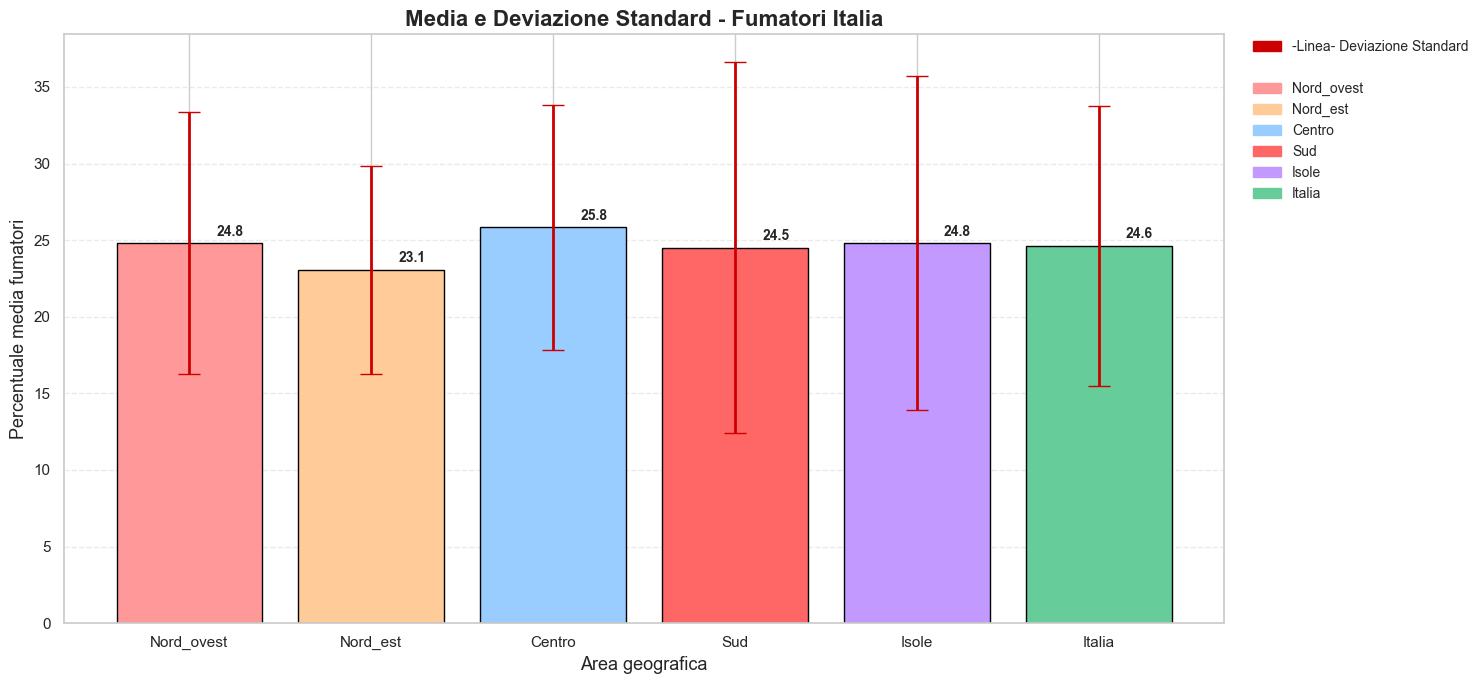

In [85]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

# Definizione delle colonne numeriche da analizzare
colonne_numeriche = ["Nord_ovest", "Nord_est", "Centro", "Sud", "Isole", "Italia"]

# Calcolo della media e della deviazione standard per ciascuna colonna
media = df[colonne_numeriche].mean()
dev_std = df[colonne_numeriche].std()

# figura 
plt.figure(figsize=(15, 7))

# Generazione del grafico a barre
bars = plt.bar(
    colonne_numeriche,
    media,
    yerr=dev_std,
    capsize=8,
    color=["#ff9999", "#ffcc99", "#99ccff", "#ff6666", "#c299ff", "#66cc99"],
    edgecolor="black",
    error_kw={
        "ecolor": "#cc0000",
        "elinewidth": 2,
    },  
)

# Aggiunta del titolo principale e delle etichette degli assi
plt.title(
    "Media e Deviazione Standard - Fumatori Italia",
    fontsize=16,
    fontweight="bold",
)
plt.xlabel("Area geografica", fontsize=13)
plt.ylabel("Percentuale media fumatori", fontsize=13)

# Attivazione della griglia di sfondo
plt.grid(axis="y", linestyle="--", alpha=0.4)

# legenda
elementi_legenda = [

        mpatches.Patch(color="#cc0000", label="-Linea- Deviazione Standard"),
    mpatches.Patch(color="none", label=""),  # Spazio vuoto divisore
    # aree geografiche
    mpatches.Patch(color="#ff9999", label="Nord_ovest"),
    mpatches.Patch(color="#ffcc99", label="Nord_est"),
    mpatches.Patch(color="#99ccff", label="Centro"),
    mpatches.Patch(color="#ff6666", label="Sud"),
    mpatches.Patch(color="#c299ff", label="Isole"),
    mpatches.Patch(color="#66cc99", label="Italia"),
]

# legenda
plt.legend(
    handles=elementi_legenda,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)

# Inserimento dei valori numerici
for bar, valore in zip(bars, media):
    pos_x = bar.get_x() + bar.get_width() / 2 + 0.15
    pos_y = bar.get_height() + 0.5

    plt.text(
        pos_x,
        pos_y,
        round(valore, 1),
        ha="left", 
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

#### Sud e Isole hanno una deviazione standard più alta.Questo indica maggiore variazione nel tempo.



### ANALISI PERCENTILI:


C:\Users\Antonella\AppData\Local\Temp\ipykernel_30496\2401741659.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


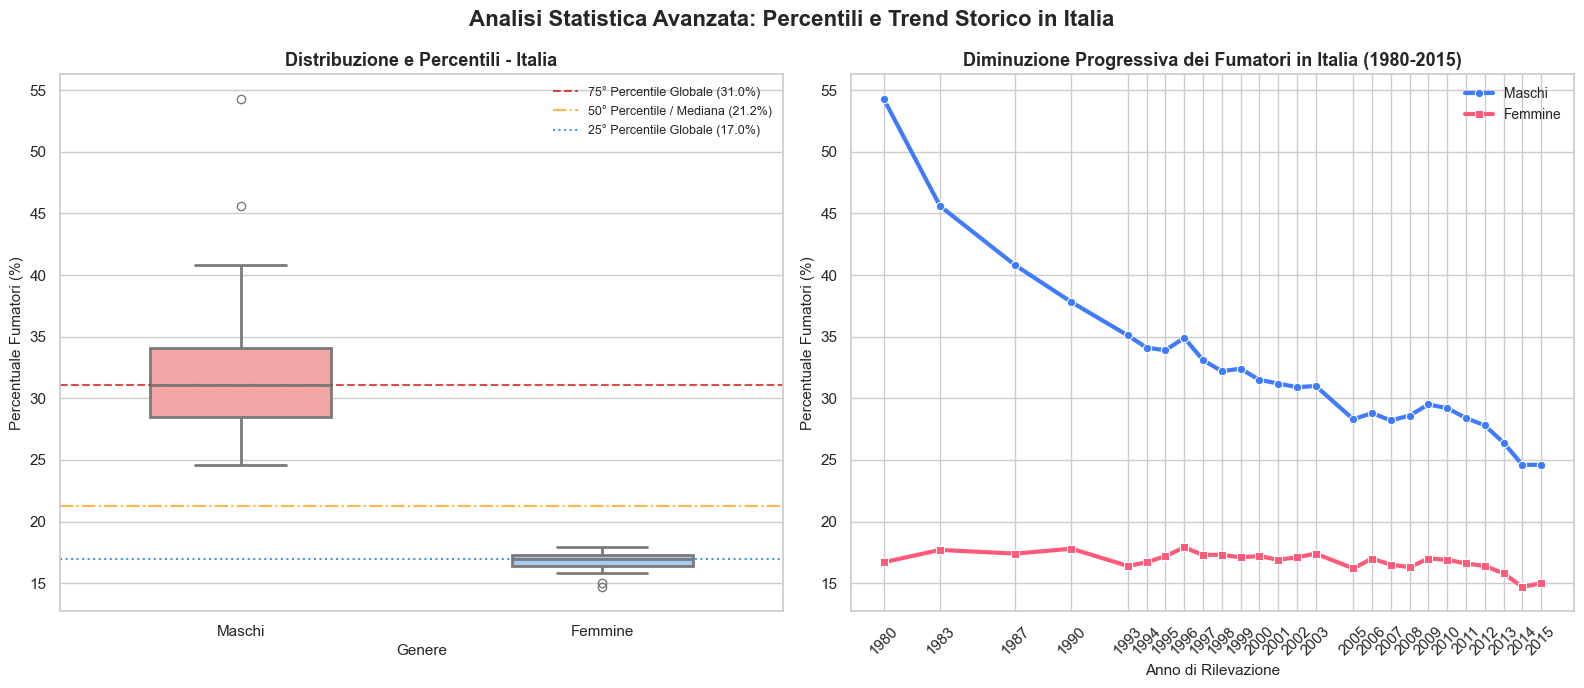

In [86]:

# Configurazione dello stile generale
sns.set_theme(style="whitegrid")

# Inizializzazione della figura con due sotto-grafici affiancati (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))


# Creazione del boxplot per la colonna 'Italia' diviso per sesso per mostrare la dispersione
sns.boxplot(
    data=df,
    x="Sesso",
    y="Italia",
    ax=ax1,
    palette=["#ff9999", "#99ccff"],
    width=0.5,
    linewidth=2,
)

# Calcolo dei percentili globali di riferimento per l'annotazione cul grafico
p25 = df["Italia"].quantile(0.25)
p50 = df["Italia"].median()
p75 = df["Italia"].quantile(0.75)

# Aggiunta di linee orizzontali tratteggiate per evidenziare i percentili globali
ax1.axhline(
    p75,
    color="#cc0000",
    linestyle="--",
    alpha=0.7,
    label=f"75° Percentile Globale ({round(p75, 1)}%)",
)
ax1.axhline(
    p50,
    color="#ff9900",
    linestyle="-.",
    alpha=0.7,
    label=f"50° Percentile / Mediana ({round(p50, 1)}%)",
)
ax1.axhline(
    p25,
    color="#0066cc",
    linestyle=":",
    alpha=0.7,
    label=f"25° Percentile Globale ({round(p25, 1)}%)",
)

ax1.set_title(
    "Distribuzione e Percentili - Italia",
    fontsize=13,
    fontweight="bold",
)
ax1.set_xlabel("Genere", fontsize=11)
ax1.set_ylabel("Percentuale Fumatori (%)", fontsize=11)
ax1.legend(loc="upper right", fontsize=9)



# Tracciamento delle linee storiche per Maschi e Femmine in Italia
sns.lineplot(
    data=df[df["Sesso"] == "Maschi"],
    x="Anno",
    y="Italia",
    ax=ax2,
    color="#407BFF",
    linewidth=3,
    marker="o",
    label="Maschi",
)
sns.lineplot(
    data=df[df["Sesso"] == "Femmine"],
    x="Anno",
    y="Italia",
    ax=ax2,
    color="#FF5A79",
    linewidth=3,
    marker="s",
    label="Femmine",
)

ax2.set_title(
    "Diminuzione Progressiva dei Fumatori in Italia (1980-2015)",
    fontsize=13,
    fontweight="bold",
)
ax2.set_xlabel("Anno di Rilevazione", fontsize=11)
ax2.set_ylabel("Percentuale Fumatori (%)", fontsize=11)
ax2.set_xticks(df["Anno"].unique())
ax2.tick_params(axis="x", rotation=45)
ax2.legend(loc="upper right", fontsize=10)

# Titolo super-superiore che unifica i due grafici
plt.suptitle(
    "Analisi Statistica Avanzata: Percentili e Trend Storico in Italia",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# Ottimizzazione degli spazi per evitare che i testi si sovrappongano
plt.tight_layout()
plt.show()



#### Boxplot (Percentili - Sinistra)
#### Alta variabilità maschile: La scatola dei maschi è ampia, segno che le percentuali di fumatori uomini ###### sono cambiate drasticamente nel tempo.

#### Stabilità femminile: La scatola delle donne è molto stretta, indicando che i dati sono rimasti concentrati e quasi invariati negli anni.

#### Grafico a linee (Trend - Destra)
#### Crollo dei maschi: La linea blu documenta una netta e costante diminuzione dei fumatori dal 1980 al 2015.

#### Situazione femminile: La linea rosa mostra un andamento quasi piatto, senza grandi variazioni storiche.

#### Il divario enorme tra i due sessi presente nel 1980 si è ridotto, portando i dati del 2015 molto più vicini tra loro.

### CURIOSITA':EVOLUZIONE FUMATORI TRA LE AREE GEOGRAFICA
 

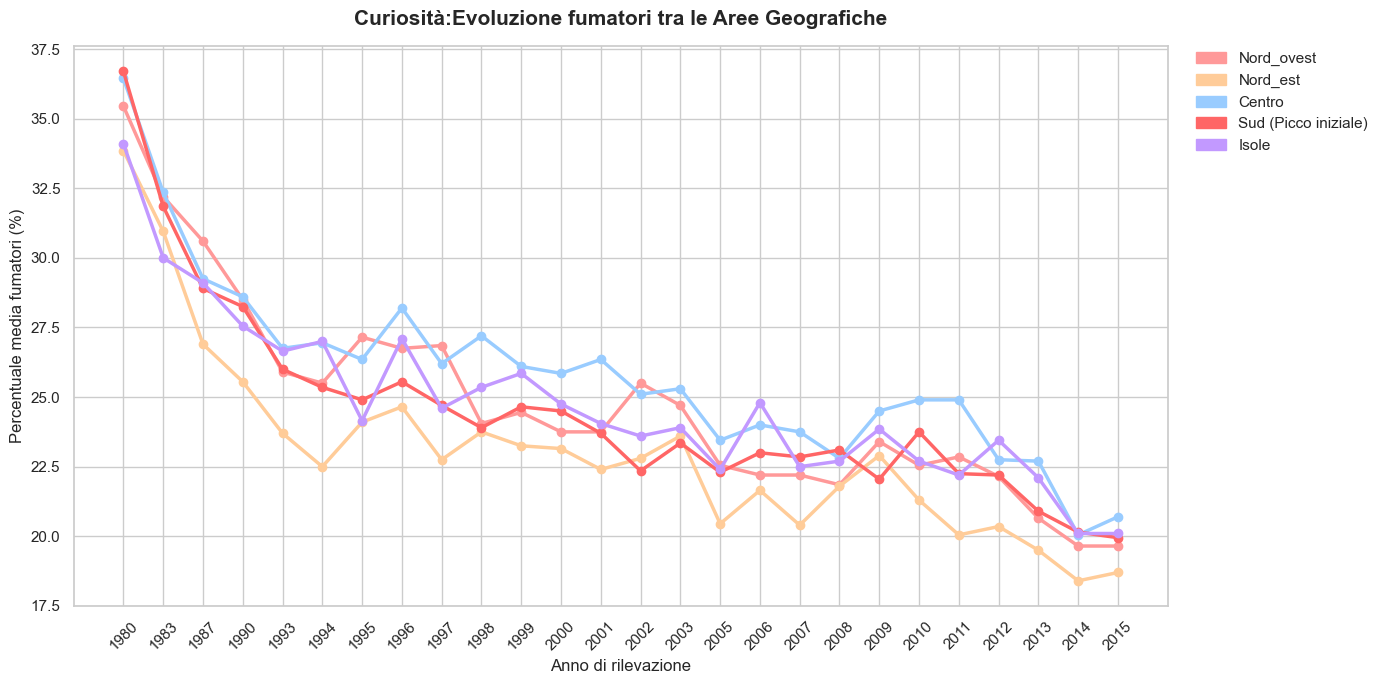

In [87]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

# Raggruppiamo i dati per Anno e calcoliamo la media per ogni singola area geografica
# Questo unifica i dati di maschi e femmine, mantenendo separate le zone
aree = ["Nord_ovest", "Nord_est", "Centro", "Sud", "Isole"]
df_linee = df.groupby("Anno")[aree].mean().reset_index()

# Ordiniamo cronologicamente 
df_linee = df_linee.sort_values("Anno")
df_linee["Anno"] = df_linee["Anno"].astype(str)

# Configurazione dello stile generale
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# colori 
colori_zone = {
    "Nord_ovest": "#ff9999",
    "Nord_est": "#ffcc99",
    "Centro": "#99ccff",
    "Sud": "#ff6666",
    "Isole": "#c299ff",
}

# linea specifica per ciascuna area geografica
for zona in aree:
    plt.plot(
        df_linee["Anno"],
        df_linee[zona],
        marker="o",
        linewidth=2.5,
        color=colori_zone[zona],
        label=zona,
    )

# Configurazione dei dettagli assi, etichette e griglia
plt.title(
    "Curiosità:Evoluzione fumatori tra le Aree Geografiche",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Anno di rilevazione", fontsize=12)
plt.ylabel("Percentuale media fumatori (%)", fontsize=12)
plt.xticks(rotation=45)

# legenda
elementi_legenda = [
    mpatches.Patch(color=colori_zone["Nord_ovest"], label="Nord_ovest"),
    mpatches.Patch(color=colori_zone["Nord_est"], label="Nord_est"),
    mpatches.Patch(color=colori_zone["Centro"], label="Centro"),
    mpatches.Patch(color=colori_zone["Sud"], label="Sud (Picco iniziale)"),
    mpatches.Patch(color=colori_zone["Isole"], label="Isole"),
]

plt.legend(
    handles=elementi_legenda,
    fontsize=11,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0,
)

# Mostra il grafico ottimizzato
plt.tight_layout()
plt.show()

#### Dal 1980 al 1995 circa si ha un crollo medio dei fumatori che poi si stabilizza e tende gradualmente a diminuire fino al 2015

### CAMBIO DATI SESSO IN 0 E 1

In [88]:
df['Sesso'] = df['Sesso'].map({
    'Maschi': 1,
    'Femmine': 0
})

#### SPLIT DEL DATASET

In [89]:
X = df[['Anno', 'Sesso', 'Nord_ovest', 'Nord_est', 'Centro', 'Sud', 'Isole']]
y = df['Italia']

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dimensioni training set:", X_train.shape)
print("Dimensioni test set:", X_test.shape)

Dimensioni training set: (41, 7)
Dimensioni test set: (11, 7)


### NORMALIZZAZIONE

In [91]:
scaler = StandardScaler()
# fit_transform SOLO sul training set
X_train_scaled = scaler.fit_transform(X_train)
# transform sul test set
X_test_scaled = scaler.transform(X_test)

### CREAZIONE MODELLO

In [92]:
model = LinearRegression()
# addestramento modello
model.fit(X_train_scaled, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### PREDIZIONI

In [93]:
predictions = model.predict(X_test_scaled)
print("\nValori reali:")
print(y_test.values)
print("\nPredizioni modello:")
print(predictions)


Valori reali:
[29.5 16.2 16.6 31.2 16.5 34.1 28.2 14.7 37.8 17.2 30.9]

Predizioni modello:
[29.56248835 16.22527704 16.57685539 31.13654727 16.4834766  34.02966232
 28.21978586 14.73312203 37.79917647 17.28007854 30.87664338]


### GRAFICO

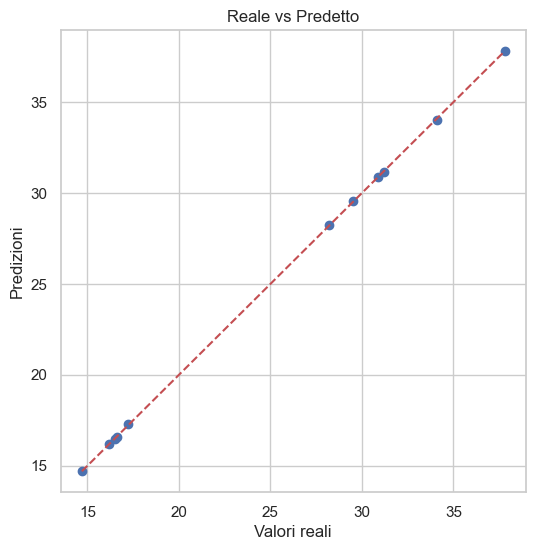

In [95]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valori reali")
plt.ylabel("Predizioni")
plt.title("Reale vs Predetto")
plt.show()



### VALIDAZIONE 

In [ ]:
# MAE = errore medio assoluto
mae = mean_absolute_error(y_test, predictions)
# MSE = errore quadratico medio
mse = mean_squared_error(y_test, predictions)
# RMSE = radice errore quadratico medio
rmse = np.sqrt(mse)
# R2 = qualità del modello
r2 = r2_score(y_test, predictions)
print("\n===== VALIDAZIONE MODELLO =====")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")


===== VALUTAZIONE MODELLO =====
MAE: 0.04
MSE: 0.00
RMSE: 0.05
R2 Score: 1.00


### GRAFICO

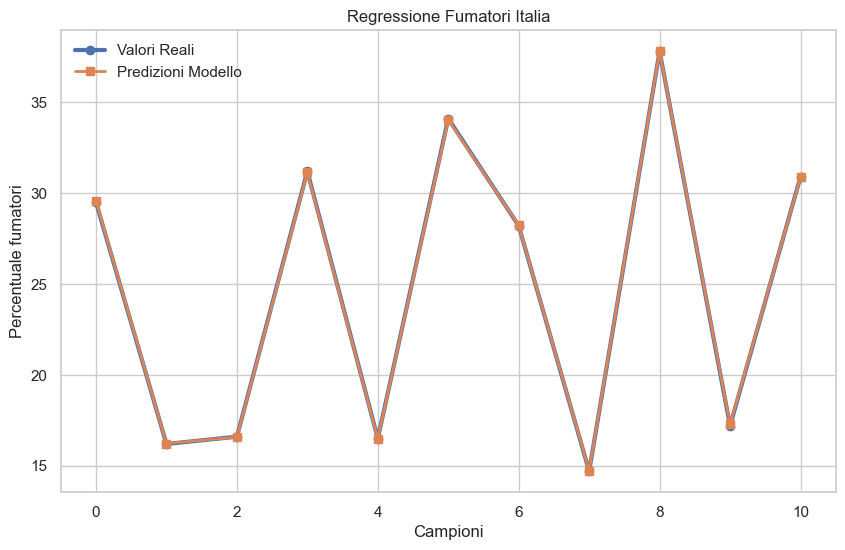

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    y_test.values,
    label='Valori Reali',
    marker='o',
    linewidth=3
)

plt.plot(
    predictions,
    label='Predizioni Modello',
    marker='s',
    linewidth=2
)

plt.title('Regressione Fumatori Italia')
plt.xlabel('Campioni')
plt.ylabel('Percentuale fumatori')
plt.legend()
plt.grid(True)
plt.show()